# 01_Python_Cleaning



1.Upload and unzip your dataset

In [ ]:
# Upload your zip file
from google.colab import files
uploaded = files.upload()

Saving northstar_dataset.zip to northstar_dataset.zip


In [ ]:
import zipfile
import os

# Unzip the dataset
with zipfile.ZipFile('northstar_dataset.zip', 'r') as z:
    z.extractall('northstar')

# Check all files are there
for f in os.listdir('northstar/northstar_dataset'):
    print(f)

deliveries.csv
orders.csv
hubs.csv
customers.csv
app_events.csv
data_dictionary.csv
complaints.csv
incidents.csv
vehicles.csv
README.txt
drivers.csv


2.Load all tables

In [ ]:
import pandas as pd

path = 'northstar/northstar_dataset/'

customers   = pd.read_csv(path + 'customers.csv')
orders      = pd.read_csv(path + 'orders.csv')
deliveries  = pd.read_csv(path + 'deliveries.csv')
drivers     = pd.read_csv(path + 'drivers.csv')
vehicles    = pd.read_csv(path + 'vehicles.csv')
hubs        = pd.read_csv(path + 'hubs.csv')
incidents   = pd.read_csv(path + 'incidents.csv')
complaints  = pd.read_csv(path + 'complaints.csv')
app_events  = pd.read_csv(path + 'app_events.csv')

print("All tables loaded successfully")
print(f"Orders: {len(orders)} rows")
print(f"Deliveries: {len(deliveries)} rows")
print(f"Customers: {len(customers)} rows")

All tables loaded successfully
Orders: 1250 rows
Deliveries: 950 rows
Customers: 650 rows


3.Fix zone names

In [ ]:
# Zone names are inconsistent across ALL tables
# North / NORTH / north / Ctr / CENTRAL all mean the same thing
# We standardise everything to: North, South, East, West, Central, Airport, Riverside

zone_map = {
    'north': 'North', 'NORTH': 'North', 'North': 'North',
    'south': 'South', 'SOUTH': 'South', 'South': 'South',
    'east':  'East',  'EAST':  'East',  'East':  'East',
    'west':  'West',  'WEST':  'West',  'West':  'West',
    'central': 'Central', 'CENTRAL': 'Central', 'Central': 'Central', 'Ctr': 'Central',
    'airport': 'Airport', 'AIRPORT': 'Airport', 'Airport': 'Airport',
    'riverside': 'Riverside', 'RIVERSIDE': 'Riverside',
    'Riverside': 'Riverside', 'RiverSide': 'Riverside',
}

# Apply to every zone column in every table
customers['home_zone']        = customers['home_zone'].map(zone_map)
orders['pickup_zone']         = orders['pickup_zone'].map(zone_map)
orders['dropoff_zone']        = orders['dropoff_zone'].map(zone_map)
drivers['base_zone']          = drivers['base_zone'].map(zone_map)
vehicles['assigned_zone']     = vehicles['assigned_zone'].map(zone_map)
hubs['zone']                  = hubs['zone'].map(zone_map)
app_events['zone_context']    = app_events['zone_context'].map(zone_map)

# Verify - should see clean zone names only
print("Unique zones in orders (pickup):")
print(sorted(orders['pickup_zone'].dropna().unique()))

Unique zones in orders (pickup):
['Airport', 'Central', 'East', 'North', 'Riverside', 'South', 'West']


4.Fix missing values

In [ ]:
# Check missing values before fixing
print("=== Missing values before cleaning ===")
for name, df in [('customers', customers), ('orders', orders),
                 ('deliveries', deliveries), ('drivers', drivers),
                 ('vehicles', vehicles), ('incidents', incidents),
                 ('complaints', complaints), ('app_events', app_events)]:
    nulls = df.isnull().sum()
    nulls = nulls[nulls > 0]
    if len(nulls) > 0:
        print(f"\n{name}:")
        print(nulls)

=== Missing values before cleaning ===

customers:
loyalty_score        20
preferred_channel    13
dtype: int64

orders:
booking_channel    25
dtype: int64

deliveries:
delivery_completed_at            19
customer_rating_post_delivery    14
dtype: int64

drivers:
training_score    7
dtype: int64

vehicles:
battery_health_pct    4
dtype: int64

incidents:
resolved_hours    17
dtype: int64

complaints:
compensation_amount    16
dtype: int64

app_events:
order_id    144
dtype: int64


5.Fill the missing values

In [ ]:
# Fill missing values sensibly for each column

# customers
customers['loyalty_score'].fillna(customers['loyalty_score'].median(), inplace=True)
customers['preferred_channel'].fillna('Unknown', inplace=True)

# orders
orders['booking_channel'].fillna('Unknown', inplace=True)

# deliveries
deliveries['delivery_completed_at'].fillna('Unknown', inplace=True)
deliveries['customer_rating_post_delivery'].fillna(
    deliveries['customer_rating_post_delivery'].median(), inplace=True)

# drivers
drivers['training_score'].fillna(drivers['training_score'].median(), inplace=True)

# vehicles
vehicles['battery_health_pct'].fillna(vehicles['battery_health_pct'].median(), inplace=True)

# incidents
incidents['resolved_hours'].fillna(incidents['resolved_hours'].median(), inplace=True)

# complaints
complaints['compensation_amount'].fillna(0, inplace=True)

# app_events - order_id missing just means it was a browse session, not linked to an order
app_events['order_id'].fillna('NO_ORDER', inplace=True)

# Confirm all clean
print("=== Missing values after cleaning ===")
for name, df in [('customers', customers), ('orders', orders),
                 ('deliveries', deliveries), ('drivers', drivers),
                 ('vehicles', vehicles), ('incidents', incidents),
                 ('complaints', complaints), ('app_events', app_events)]:
    nulls = df.isnull().sum().sum()
    print(f"{name}: {nulls} missing values remaining")

=== Missing values after cleaning ===
customers: 0 missing values remaining
orders: 0 missing values remaining
deliveries: 0 missing values remaining
drivers: 0 missing values remaining
vehicles: 0 missing values remaining
incidents: 0 missing values remaining
complaints: 0 missing values remaining
app_events: 0 missing values remaining


/tmp/ipykernel_14792/2611090556.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  customers['loyalty_score'].fillna(customers['loyalty_score'].median(), inplace=True)
/tmp/ipykernel_14792/2611090556.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[c

 6.Fix warnings and save clean datasets

In [ ]:
# Redo fillna using modern pandas syntax (no warnings)
customers['loyalty_score']                 = customers['loyalty_score'].fillna(customers['loyalty_score'].median())
customers['preferred_channel']             = customers['preferred_channel'].fillna('Unknown')
orders['booking_channel']                  = orders['booking_channel'].fillna('Unknown')
deliveries['delivery_completed_at']        = deliveries['delivery_completed_at'].fillna('Unknown')
deliveries['customer_rating_post_delivery']= deliveries['customer_rating_post_delivery'].fillna(deliveries['customer_rating_post_delivery'].median())
drivers['training_score']                  = drivers['training_score'].fillna(drivers['training_score'].median())
vehicles['battery_health_pct']             = vehicles['battery_health_pct'].fillna(vehicles['battery_health_pct'].median())
incidents['resolved_hours']                = incidents['resolved_hours'].fillna(incidents['resolved_hours'].median())
complaints['compensation_amount']          = complaints['compensation_amount'].fillna(0)
app_events['order_id']                     = app_events['order_id'].fillna('NO_ORDER')

# Save all clean files so other notebooks can use them
import os
os.makedirs('clean', exist_ok=True)

customers.to_csv('clean/customers.csv',   index=False)
orders.to_csv('clean/orders.csv',         index=False)
deliveries.to_csv('clean/deliveries.csv', index=False)
drivers.to_csv('clean/drivers.csv',       index=False)
vehicles.to_csv('clean/vehicles.csv',     index=False)
hubs.to_csv('clean/hubs.csv',             index=False)
incidents.to_csv('clean/incidents.csv',   index=False)
complaints.to_csv('clean/complaints.csv', index=False)
app_events.to_csv('clean/app_events.csv', index=False)

print("All clean files saved to /clean folder")
print(os.listdir('clean'))

All clean files saved to /clean folder
['deliveries.csv', 'orders.csv', 'hubs.csv', 'customers.csv', 'app_events.csv', 'complaints.csv', 'incidents.csv', 'vehicles.csv', 'drivers.csv']


7.Chart 1: Delivery status by zone

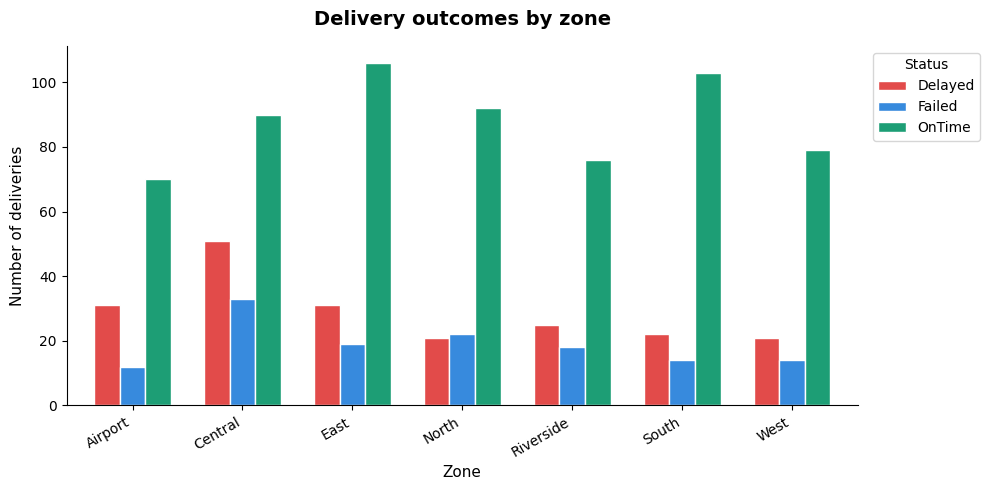

Chart 1 saved


In [ ]:
import matplotlib.pyplot as plt
import matplotlib
import numpy as np

# Merge deliveries with orders to get zone info
del_orders = deliveries.merge(orders[['order_id','pickup_zone','service_type']],
                               on='order_id', how='left')

# Count delivery status by zone
status_zone = del_orders.groupby(['pickup_zone','delivery_status']).size().unstack(fill_value=0)

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
status_zone.plot(kind='bar', ax=ax, color=['#E24B4A','#378ADD','#1D9E75'],
                 edgecolor='white', width=0.7)

ax.set_title('Delivery outcomes by zone', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Zone', fontsize=11)
ax.set_ylabel('Number of deliveries', fontsize=11)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
ax.legend(title='Status', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('clean/chart1_delivery_by_zone.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 1 saved")

8.Chart 2: Manual route overrides vs delivery failures by driver

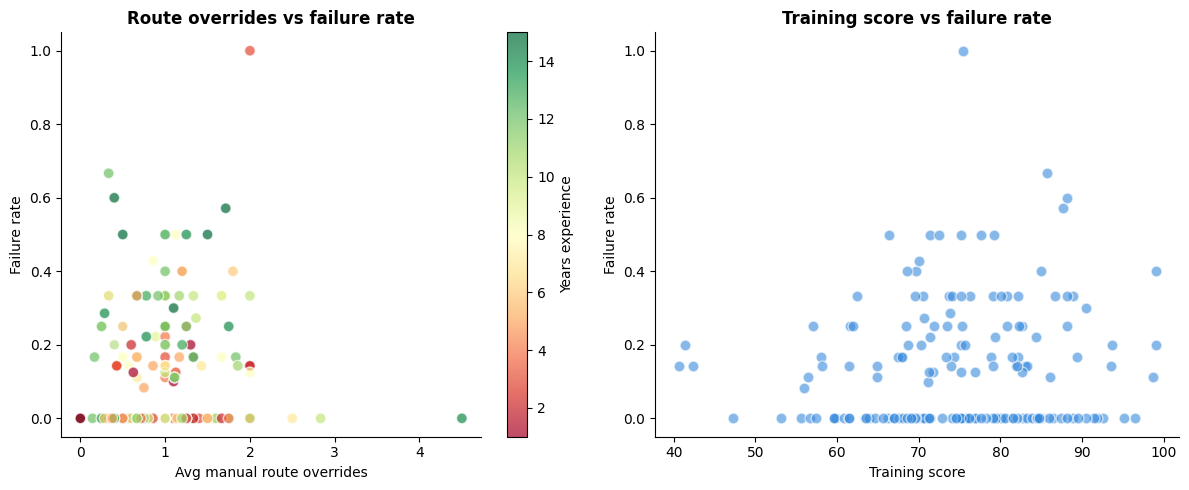

Chart 2 saved


In [ ]:
# Merge deliveries with drivers
del_drivers = deliveries.merge(drivers[['driver_id','years_experience','training_score','driver_rating']],
                                on='driver_id', how='left')

# Create failure flag
del_drivers['failed'] = (del_drivers['delivery_status'] == 'Failed').astype(int)

# Group by driver
driver_summary = del_drivers.groupby('driver_id').agg(
    avg_overrides   = ('manual_route_override_count', 'mean'),
    failure_rate    = ('failed', 'mean'),
    experience      = ('years_experience', 'first'),
    training        = ('training_score', 'first')
).reset_index()

# Plot: overrides vs failure rate, coloured by experience
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: overrides vs failure rate
sc = axes[0].scatter(driver_summary['avg_overrides'],
                     driver_summary['failure_rate'],
                     c=driver_summary['experience'],
                     cmap='RdYlGn', alpha=0.7, edgecolors='white', s=60)
plt.colorbar(sc, ax=axes[0], label='Years experience')
axes[0].set_title('Route overrides vs failure rate', fontweight='bold')
axes[0].set_xlabel('Avg manual route overrides')
axes[0].set_ylabel('Failure rate')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Right: training score vs failure rate
axes[1].scatter(driver_summary['training'],
                driver_summary['failure_rate'],
                color='#378ADD', alpha=0.6, edgecolors='white', s=60)
axes[1].set_title('Training score vs failure rate', fontweight='bold')
axes[1].set_xlabel('Training score')
axes[1].set_ylabel('Failure rate')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('clean/chart2_driver_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 2 saved")

9.Chart 3: Complaint types and resolution times

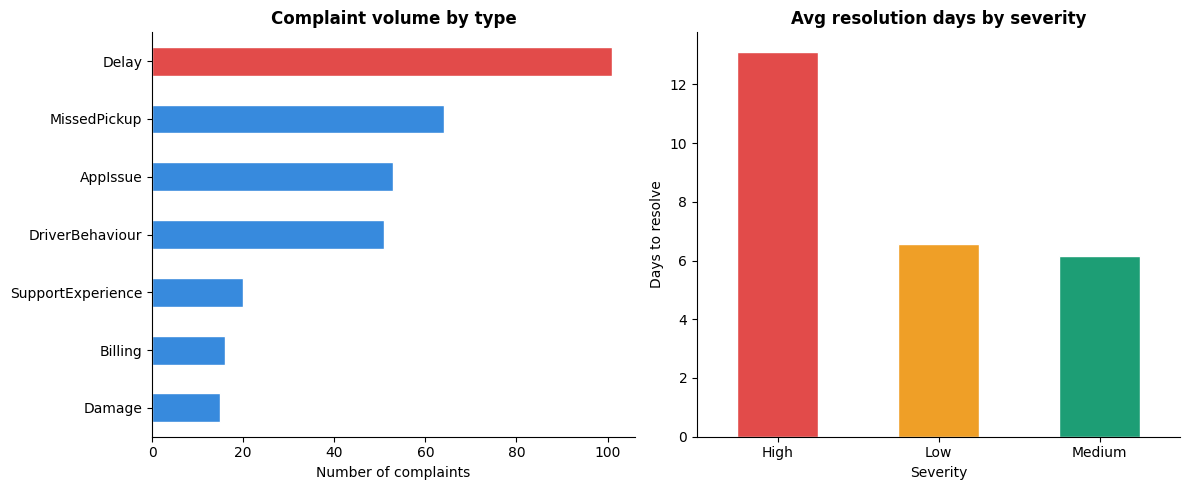

Chart 3 saved


In [ ]:
# Complaints by type and severity
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: complaint volume by type
complaint_counts = complaints.groupby('complaint_type').size().sort_values(ascending=True)
colors = ['#E24B4A' if x == complaint_counts.max() else '#378ADD' for x in complaint_counts]

complaint_counts.plot(kind='barh', ax=axes[0], color=colors, edgecolor='white')
axes[0].set_title('Complaint volume by type', fontweight='bold')
axes[0].set_xlabel('Number of complaints')
axes[0].set_ylabel('')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Right: avg resolution days by severity
resolution = complaints.groupby('severity')['resolution_days'].mean().sort_values(ascending=False)
resolution.plot(kind='bar', ax=axes[1],
                color=['#E24B4A','#EF9F27','#1D9E75'], edgecolor='white', width=0.5)
axes[1].set_title('Avg resolution days by severity', fontweight='bold')
axes[1].set_xlabel('Severity')
axes[1].set_ylabel('Days to resolve')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('clean/chart3_complaints.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 3 saved")

10.Chart 4: Hub performance and vehicle maintenance

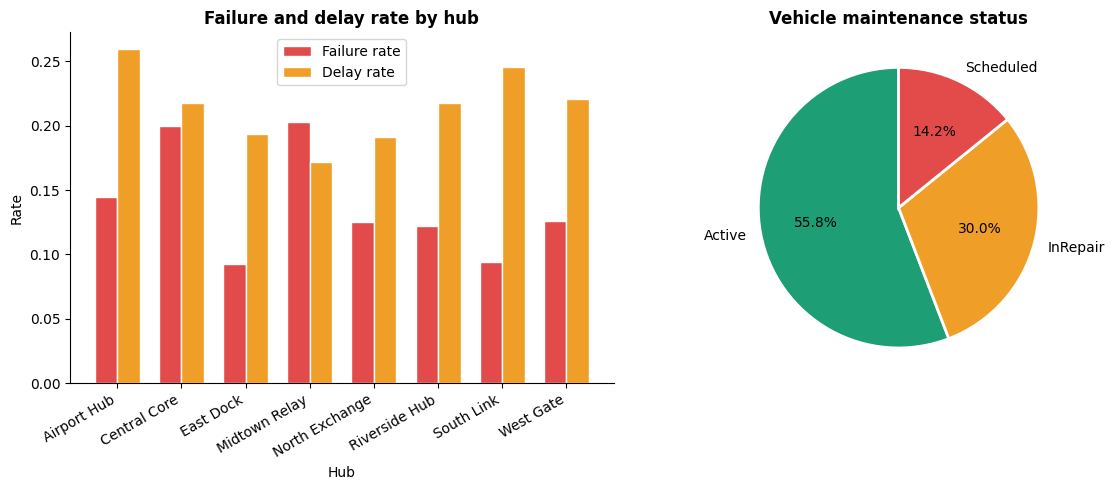

Chart 4 saved


In [ ]:
# Merge deliveries with hubs
del_hubs = deliveries.merge(hubs[['hub_id','hub_name','zone','capacity_score']],
                             on='hub_id', how='left')

# Hub failure rate and avg cost
hub_summary = del_hubs.groupby('hub_name').agg(
    failure_rate  = ('delivery_status', lambda x: (x == 'Failed').mean()),
    delay_rate    = ('delivery_status', lambda x: (x == 'Delayed').mean()),
    avg_cost      = ('fuel_or_charge_cost', 'mean'),
    total         = ('delivery_id', 'count')
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: failure and delay rate by hub
x = np.arange(len(hub_summary))
width = 0.35
axes[0].bar(x - width/2, hub_summary['failure_rate'], width,
            label='Failure rate', color='#E24B4A', edgecolor='white')
axes[0].bar(x + width/2, hub_summary['delay_rate'],   width,
            label='Delay rate',   color='#EF9F27', edgecolor='white')
axes[0].set_title('Failure and delay rate by hub', fontweight='bold')
axes[0].set_xlabel('Hub')
axes[0].set_ylabel('Rate')
axes[0].set_xticks(x)
axes[0].set_xticklabels(hub_summary['hub_name'], rotation=30, ha='right')
axes[0].legend()
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Right: vehicle maintenance status breakdown
vehicle_status = vehicles['maintenance_status'].value_counts()
colors_pie = ['#1D9E75','#EF9F27','#E24B4A']
axes[1].pie(vehicle_status, labels=vehicle_status.index, autopct='%1.1f%%',
            colors=colors_pie, startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('Vehicle maintenance status', fontweight='bold')

plt.tight_layout()
plt.savefig('clean/chart4_hub_vehicles.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 4 saved")

Python summary stats for your report

In [ ]:
# Key numbers to quote in your report

print("=" * 50)
print("NORTHSTAR — KEY FINDINGS SUMMARY")
print("=" * 50)

# Delivery performance
total = len(deliveries)
failed  = (deliveries['delivery_status'] == 'Failed').sum()
delayed = (deliveries['delivery_status'] == 'Delayed').sum()
ontime  = (deliveries['delivery_status'] == 'OnTime').sum()
print(f"\nDelivery performance ({total} total):")
print(f"  On time : {ontime}  ({ontime/total*100:.1f}%)")
print(f"  Delayed : {delayed} ({delayed/total*100:.1f}%)")
print(f"  Failed  : {failed}  ({failed/total*100:.1f}%)")

# Worst zone
zone_fail = del_orders.groupby('pickup_zone')['delivery_status'].apply(
    lambda x: (x == 'Failed').mean()).sort_values(ascending=False)
print(f"\nHighest failure rate zone: {zone_fail.index[0]} ({zone_fail.iloc[0]*100:.1f}%)")
print(f"Lowest  failure rate zone: {zone_fail.index[-1]} ({zone_fail.iloc[-1]*100:.1f}%)")

# Complaints
print(f"\nComplaints total: {len(complaints)}")
print(f"Top complaint type: {complaints['complaint_type'].value_counts().index[0]}")
print(f"Open complaints: {(complaints['status'] == 'Open').sum()}")

# Drivers
high_override = (deliveries['manual_route_override_count'] > 2).sum()
print(f"\nDeliveries with 2+ route overrides: {high_override} ({high_override/total*100:.1f}%)")

# Vehicles
in_repair = (vehicles['maintenance_status'] == 'InRepair').sum()
print(f"\nVehicles currently in repair: {in_repair} out of {len(vehicles)}")

print("\n" + "=" * 50)
print("Python notebook complete — ready for SQL in R")
print("=" * 50)

NORTHSTAR — KEY FINDINGS SUMMARY

Delivery performance (950 total):
  On time : 616  (64.8%)
  Delayed : 202 (21.3%)
  Failed  : 132  (13.9%)

Highest failure rate zone: Central (19.0%)
Lowest  failure rate zone: South (10.1%)

Complaints total: 320
Top complaint type: Delay
Open complaints: 56

Deliveries with 2+ route overrides: 88 (9.3%)

Vehicles currently in repair: 36 out of 120

Python notebook complete — ready for SQL in R
